#  <h1 align="center">Descriptive Analysis</h1>

## 1 . Glucose Level Distribution: How much time do patients spend in Hypoglycemia, Normal, and Hyperglycemia zones?

#### Why I chose this Biomarker: Glucose is the core clinical variable in a diabetes dataset. It directly measures how well blood sugar is being controlled.
#### Why it's important to the medical condition: T1DM patients must maintain glucose between 70–180 mg/dL. Time spent outside this range especially in hypoglycemia (<70) which is dangerous and life-threatening. This analysis reveals which patients have the poorest glucose control.

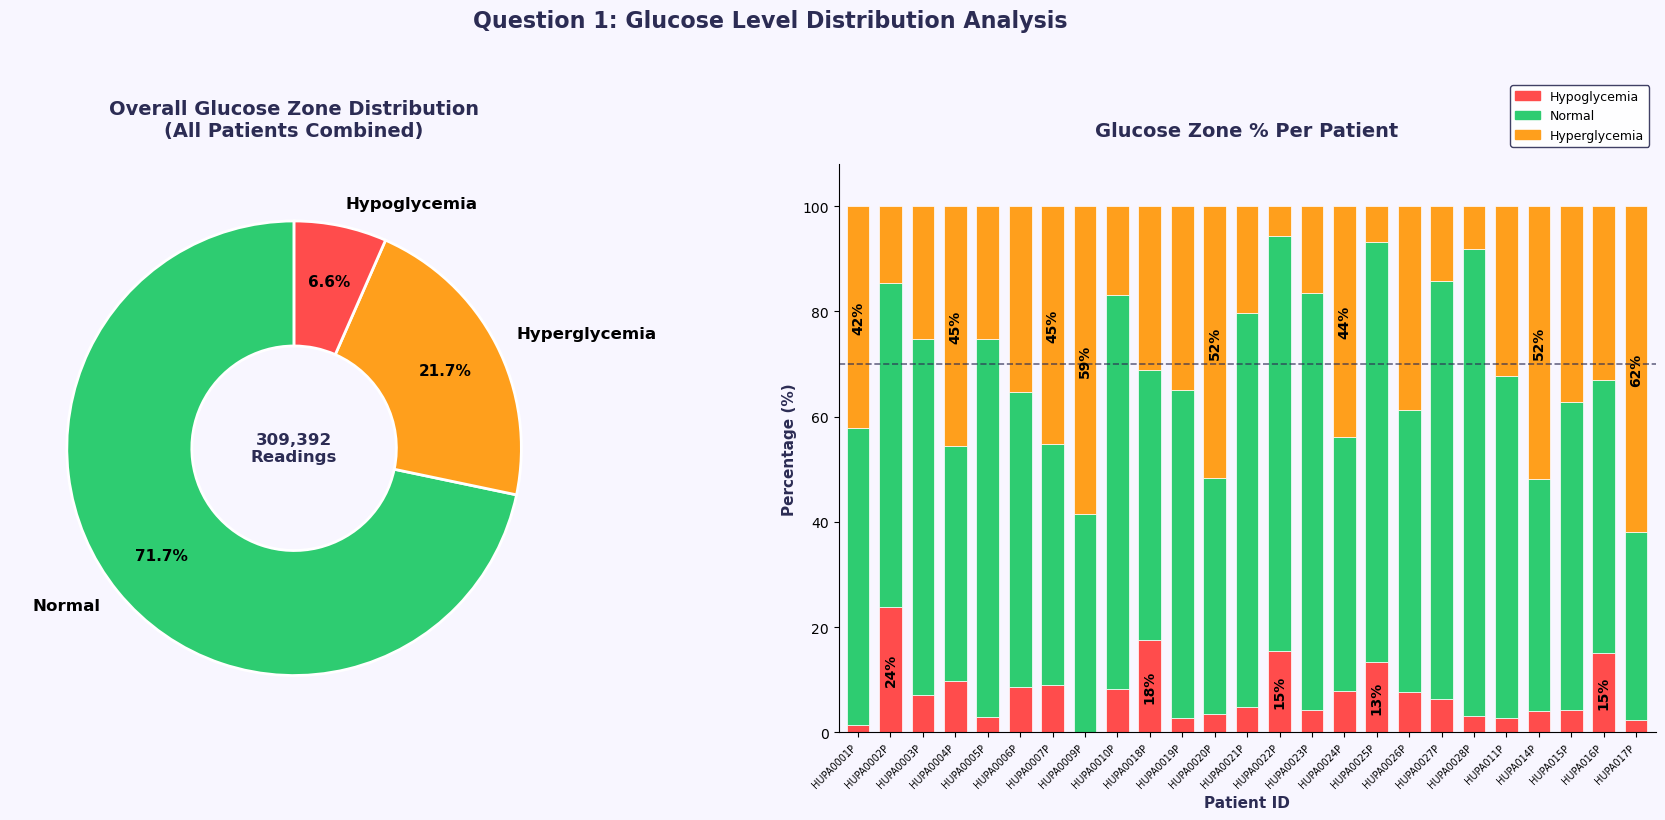

Chart saved successfully!

=== Overall Glucose Zone Distribution ===
  Normal         : 71.7%
  Hyperglycemia  : 21.7%
  Hypoglycemia   : 6.6%

Most at-risk patient : HUPA0002P (23.86% hypoglycemia)
Best controlled      : HUPA0028P (88.79% normal range)


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Final_Cleaned_File.csv"
)

# ── Classify Glucose Zones ────────────────────────────────────────────────────
def classify_glucose(g):
    if g < 70:
        return 'Hypoglycemia'
    elif g <= 180:
        return 'Normal'
    else:
        return 'Hyperglycemia'

df['Glucose_Zone'] = df['Glucose'].apply(classify_glucose)

# ── Zone Colors ───────────────────────────────────────────────────────────────
zone_colors = {
    'Hypoglycemia'  : '#FF4C4C',
    'Normal'        : '#2ECC71',
    'Hyperglycemia' : '#FF9F1C'
}

# ── Overall Distribution ──────────────────────────────────────────────────────
zone_counts = df['Glucose_Zone'].value_counts()
zone_pct    = (zone_counts / len(df) * 100).round(2)

# ── Per Patient Breakdown ─────────────────────────────────────────────────────
patient_zone = (
    df.groupby(['Patient_Id', 'Glucose_Zone'])
    .size()
    .unstack(fill_value=0)
)
patient_zone_pct = (
    patient_zone.div(patient_zone.sum(axis=1), axis=0) * 100
).round(2)

for col in ['Hypoglycemia', 'Normal', 'Hyperglycemia']:
    if col not in patient_zone_pct.columns:
        patient_zone_pct[col] = 0
patient_zone_pct = patient_zone_pct[['Hypoglycemia', 'Normal', 'Hyperglycemia']]

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#F8F6FF')

# ── Donut Chart ───────────────────────────────────────────────────────────────
wedge_colors = [zone_colors[z] for z in zone_pct.index]
wedges, texts, autotexts = axes[0].pie(
    zone_pct.values,
    labels=zone_pct.index,
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('black')

axes[0].set_title('Overall Glucose Zone Distribution\n(All Patients Combined)',
                  fontsize=14, fontweight='bold', pad=20, color='#2C2C54')
axes[0].set_facecolor('#F8F6FF')
axes[0].text(0, 0, f'{len(df):,}\nReadings',
             ha='center', va='center',
             fontsize=12, fontweight='bold', color='#2C2C54')

# ── Stacked Bar Chart ─────────────────────────────────────────────────────────
bar_colors = [zone_colors[z] for z in ['Hypoglycemia', 'Normal', 'Hyperglycemia']]
patient_zone_pct.plot(
    kind='bar',
    stacked=True,
    color=bar_colors,
    ax=axes[1],
    edgecolor='white',
    linewidth=0.5,
    width=0.7,
    legend=False
)

# ── Add % Labels for High Risk Patients ───────────────────────────────────────
for i, patient in enumerate(patient_zone_pct.index):
    hypo_pct  = patient_zone_pct.loc[patient, 'Hypoglycemia']
    hyper_pct = patient_zone_pct.loc[patient, 'Hyperglycemia']

    # Hypoglycemia label — inside the red bar, rotated vertical
    if hypo_pct > 10:
        axes[1].text(
            i, hypo_pct / 2,
            f'{hypo_pct:.0f}%',
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color='black',
            rotation=90
        )

    # Hyperglycemia label — inside the orange bar, rotated vertical
    if hyper_pct > 40:
        normal_pct = patient_zone_pct.loc[patient, 'Normal']
        axes[1].text(
            i, hypo_pct + normal_pct + hyper_pct / 2,
            f'{hyper_pct:.0f}%',
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color='black',
            rotation=90
        )

axes[1].set_title('Glucose Zone % Per Patient',
                  fontsize=14, fontweight='bold', pad=20, color='#2C2C54')
axes[1].set_xlabel('Patient ID', fontsize=11, fontweight='bold', color='#2C2C54')
axes[1].set_ylabel('Percentage (%)', fontsize=11, fontweight='bold', color='#2C2C54')
axes[1].tick_params(axis='x', labelsize=7)
axes[1].set_xticklabels(patient_zone_pct.index, rotation=45, ha='right')
axes[1].set_facecolor('#F8F6FF')
axes[1].set_ylim(0, 108)              # ← increased to give space for labels above bars
axes[1].axhline(y=70, color='#2C2C54', linestyle='--', linewidth=1.2, alpha=0.7)
axes[1].spines[['top', 'right']].set_visible(False)

# ── Legend — Top Right Corner Outside Chart ───────────────────────────────────
patches = [mpatches.Patch(color=zone_colors[z], label=z)
           for z in ['Hypoglycemia', 'Normal', 'Hyperglycemia']]
axes[1].legend(
    handles=patches,
    loc='upper right',
    bbox_to_anchor=(1.0, 1.15),
    ncol=1,
    fontsize=9,
    framealpha=0.9,
    edgecolor='#2C2C54'
)

plt.suptitle('Question 1: Glucose Level Distribution Analysis',
             fontsize=16, fontweight='bold', color='#2C2C54', y=1.02)
plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Q1_Glucose_Distribution.png",
    dpi=150, bbox_inches='tight', facecolor='#F8F6FF'
)
plt.show()
print("Chart saved successfully!")

# ── Summary Stats ─────────────────────────────────────────────────────────────
print("\n=== Overall Glucose Zone Distribution ===")
for zone, pct in zone_pct.items():
    print(f"  {zone:15}: {round(pct, 1)}%")
    
most_at_risk = patient_zone_pct['Hypoglycemia'].idxmax()
print(f"\nMost at-risk patient : {most_at_risk} "
      f"({patient_zone_pct.loc[most_at_risk, 'Hypoglycemia']}% hypoglycemia)")
print(f"Best controlled      : {patient_zone_pct['Normal'].idxmax()} "
      f"({patient_zone_pct['Normal'].max()}% normal range)")

#### Insight:
#### In doughnut chart Out of 309,392 total glucose readings across all 25 patients, 71.7% are in the safe normal range. However, 21.7% show high glucose (hyperglycemia) and 6.6% show dangerously low glucose (hypoglycemia) — meaning patients are spending nearly 30% of their time outside the safe zone.
#### In Stacked Bar Chart High Hypoglycemia patients (red labels): HUPA0002P is the most at-risk patient with 24% of readings in the danger low zone  meaning 1 in every 4 readings was a potentially life-threatening low glucose episode. HUPA0018P (18%), HUPA0022P (15%), and HUPA016P (15%) also show alarmingly high hypoglycemia rates that need immediate clinical attention. 
#### High Hyperglycemia patients (orange labels): HUPA017P has the highest hyperglycemia at 62% — spending more than half their recorded time with dangerously high glucose. HUPA0009P (59%), HUPA014P and HUPA0020P (both around 52%) also show persistently elevated glucose levels that silently damage organs over time.
#### Hence This analysis shows that while most patients maintain safe glucose levels most of the time, there are critical outliers on both ends patients dangerously low and dangerously high and these charts instantly tells us exactly who they are.


 ## 2. Does Carbohydrate Intake Trigger a Rise in Glucose Levels?


#### Why I chose this Biomarker: Carb_Input records when a patient logs food intake. Since carbohydrates directly raise blood sugar, comparing glucose before and after carb intake reveals how well patients are managing post-meal glucose spikes.
#### Why it's important to the medical condition: Post-meal hyperglycemia is one of the biggest risks for T1DM patients. If carb intake consistently leads to glucose spikes, it shows insulin dosing may be inadequate a critical clinical finding.

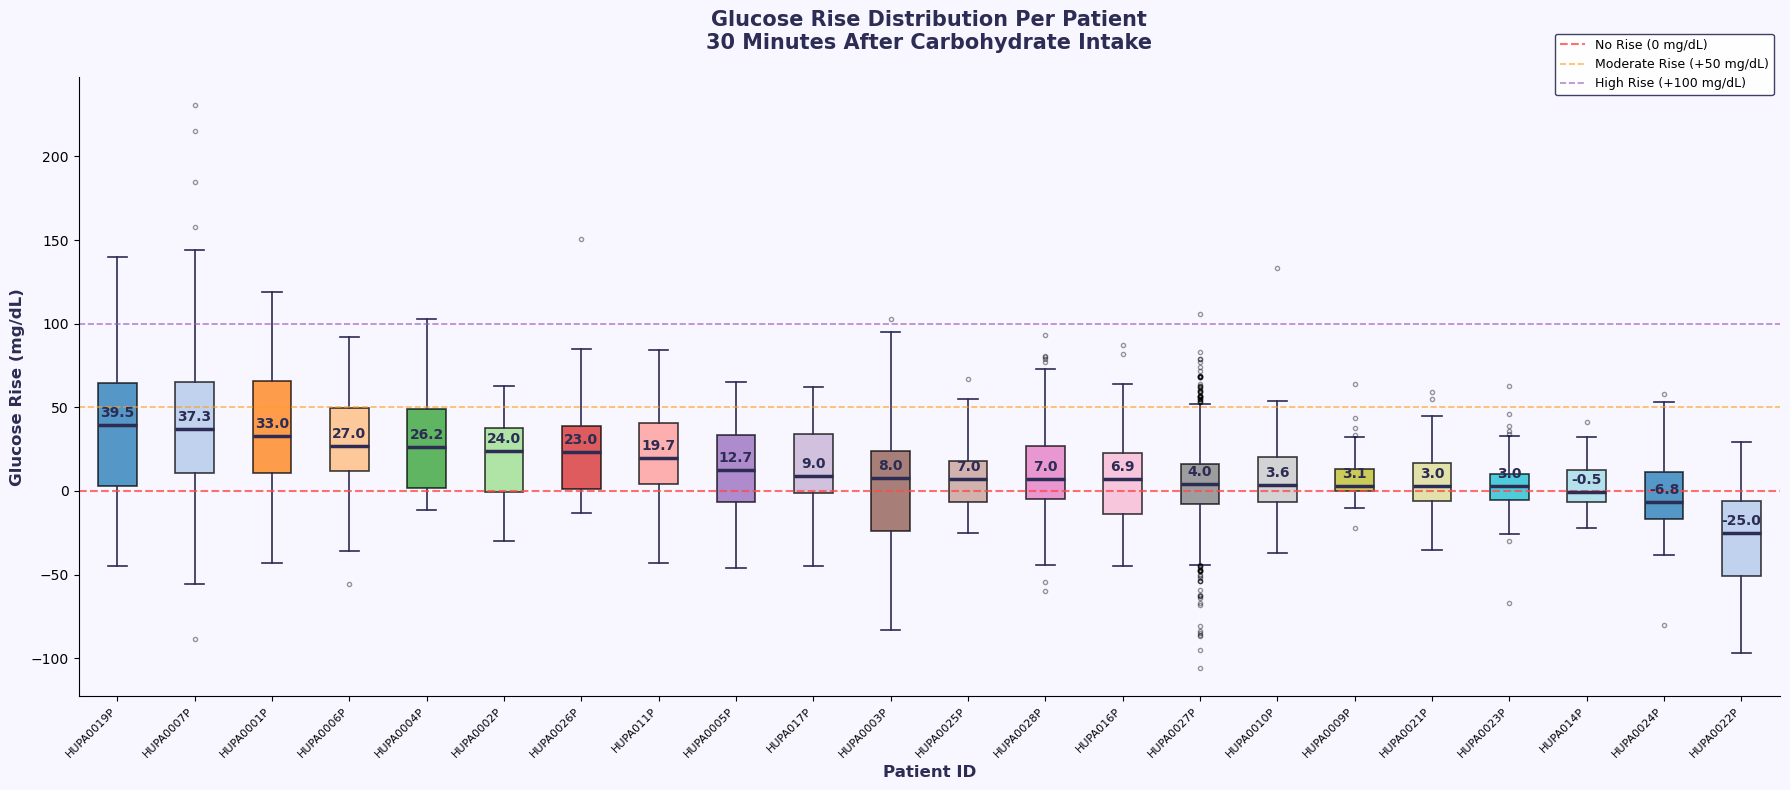

Chart saved successfully!

Total carb events         : 2641
Avg glucose before intake : 120.97 mg/dL
Avg glucose 30 min later  : 129.45 mg/dL
Avg glucose rise          : 8.47 mg/dL
Events where glucose rose : 1608
Events where glucose fell : 982

Highest median rise : HUPA0019P (39.5 mg/dL)
Lowest median rise  : HUPA0022P (-25.0 mg/dL)


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Final_Cleaned_File.csv"
)

df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df = df.sort_values(['Patient_Id', 'Time']).reset_index(drop=True)

# ── Fast Carb Event Extraction (no loop) ─────────────────────────────────────
carb_events = df[df['Carb_Input'] > 0].copy()
carb_events['Glucose_At_Intake']   = carb_events['Glucose']

# Shift glucose by 6 rows (30 min) within each patient group
df['Glucose_30min_Later'] = df.groupby('Patient_Id')['Glucose'].shift(-6)

carb_events = carb_events.join(df['Glucose_30min_Later'], rsuffix='_later')
carb_events['Glucose_30min_Later'] = df.loc[carb_events.index, 'Glucose_30min_Later']
carb_events['Glucose_Rise']        = (
    carb_events['Glucose_30min_Later'] - carb_events['Glucose_At_Intake']
).round(2)
carb_events = carb_events.dropna(subset=['Glucose_Rise'])

# ── Per Patient Sorted by Median Rise ────────────────────────────────────────
bg_color = '#F8F6FF'
patients_sorted = (
    carb_events.groupby('Patient_Id')['Glucose_Rise']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

box_data = [
    carb_events[carb_events['Patient_Id'] == p]['Glucose_Rise'].values
    for p in patients_sorted
]

palette     = plt.cm.tab20.colors
box_colors  = [palette[i % 20] for i in range(len(patients_sorted))]

# ── Box Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor(bg_color)

bp = ax.boxplot(
    box_data,
    vert=True,
    patch_artist=True,
    notch=False,
    showfliers=True,
    flierprops=dict(marker='o', markersize=3, alpha=0.4, color='grey'),
    medianprops=dict(color='#2C2C54', linewidth=2.5),
    whiskerprops=dict(linewidth=1.2, color='#2C2C54'),
    capprops=dict(linewidth=1.2, color='#2C2C54'),
    boxprops=dict(linewidth=1.2)
)

# Fill colours
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Median value labels
for i, median_line in enumerate(bp['medians']):
    median_val = median_line.get_ydata()[0]
    ax.text(
        i + 1, median_val + 3,
        f'{median_val:.1f}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#2C2C54'
    )

# Reference lines
ax.axhline(y=0,   color='#FF4C4C', linestyle='--', linewidth=1.5,
           alpha=0.8, label='No Rise (0 mg/dL)')
ax.axhline(y=50,  color='#FF9F1C', linestyle='--', linewidth=1.2,
           alpha=0.7, label='Moderate Rise (+50 mg/dL)')
ax.axhline(y=100, color='#9B59B6', linestyle='--', linewidth=1.2,
           alpha=0.7, label='High Rise (+100 mg/dL)')

ax.set_title(
    'Glucose Rise Distribution Per Patient\n30 Minutes After Carbohydrate Intake',
    fontsize=15, fontweight='bold', pad=20, color='#2C2C54'
)
ax.set_xlabel('Patient ID', fontsize=12, fontweight='bold', color='#2C2C54')
ax.set_ylabel('Glucose Rise (mg/dL)', fontsize=12, fontweight='bold', color='#2C2C54')
ax.set_xticks(range(1, len(patients_sorted) + 1))
ax.set_xticklabels(patients_sorted, rotation=45, ha='right', fontsize=8)
ax.set_facecolor(bg_color)
ax.spines[['top', 'right']].set_visible(False)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.0, 1.08),
    ncol=1, fontsize=9,
    framealpha=0.9, edgecolor='#2C2C54'
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Q2_Glucose_Rise_Boxplot.png",
    dpi=150, bbox_inches='tight', facecolor=bg_color
)
plt.show()
print("Chart saved successfully!")

# ── Summary Stats ─────────────────────────────────────────────────────────────
print(f"\nTotal carb events         : {len(carb_events)}")
print(f"Avg glucose before intake : {round(carb_events['Glucose_At_Intake'].mean(), 2)} mg/dL")
print(f"Avg glucose 30 min later  : {round(carb_events['Glucose_30min_Later'].mean(), 2)} mg/dL")
print(f"Avg glucose rise          : {round(carb_events['Glucose_Rise'].mean(), 2)} mg/dL")
print(f"Events where glucose rose : {(carb_events['Glucose_Rise'] > 0).sum()}")
print(f"Events where glucose fell : {(carb_events['Glucose_Rise'] < 0).sum()}")

top = carb_events.groupby('Patient_Id')['Glucose_Rise'].median().sort_values(ascending=False)
print(f"\nHighest median rise : {top.index[0]} ({top.iloc[0]:.1f} mg/dL)")
print(f"Lowest median rise  : {top.index[-1]} ({top.iloc[-1]:.1f} mg/dL)")

#### Insight:

#### Patients most affected by carb intake : HUPA0019P shows the highest median glucose rise of 39.5 mg/dL after eating meaning their insulin dose is consistently insufficient to control post-meal glucose spikes. HUPA0007P (37.3) and HUPA0001P (33.0) also show significant rises, indicating poor post-meal glucose control.
#### Patient with opposite reaction : HUPA0022P shows a negative median of -25.0 mg/dL  means glucose actually dropped after carb intake. This suggests the patient is over-correcting with insulin before meals, which is equally dangerous as it can lead to hypoglycemia.
#### Unpredictable patients: Patients with very wide boxes and long whiskers like HUPA0027P  have highly inconsistent glucose responses to carb intake. Some meals cause no rise at all while others cause extreme spikes above 200 mg/dL. This unpredictability makes diabetes management very difficult for these patients.
#### Hence Across 2,641 carbohydrate intake events, the average glucose rose from 120.97 mg/dL to 129.45 mg/dL is an average rise of 8.47 mg/dL within 30 minutes. This confirms that carbohydrate intake does trigger a glucose rise in diabetic patients.